# MedicaLeaf - klasifikacija lekovitog bilja

Cilj projekta je da na osnovu slike lista prepozna o kojoj vrsti
lekovite biljke se radi.

Notebook prati tok rada od početka do kraja: podaci, model i rezultati.
Deo koda koji se ponavlja (učitavanje, priprema, trening, provera
rezultata) je izdvojen u posebne fajlove radi preglednosti.

In [55]:
import os
import sys

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, datasets
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader
sys.path.append("src")
from data_utils import build_dataframe, plot_class_distribution, save_augmented_dataset, show_sample_images
from leaf_dataset import LeafDataset
from train_utils import train_model, plot_losses, set_seed
from evaluate import evaluate_model

## 1. Učitavanje podataka

Svaka vrsta biljke ima svoj folder sa slikama. Prvo pogledamo koje sve
vrste biljaka imamo u datasetu, a zatim napravimo pregled - koja slika
pripada kojoj vrsti.

Pored toga postavljamo seed 

In [56]:
set_seed(42)
DATA_DIR = "data/Medicinal Leaf Dataset/Segmented Medicinal Leaf Images"
print(os.listdir(DATA_DIR))
print("Broj klasa:", len(os.listdir(DATA_DIR)))

['Syzygium Cumini (Jamun)', 'Psidium Guajava (Guava)', 'Artocarpus Heterophyllus (Jackfruit)', 'Muntingia Calabura (Jamaica Cherry-Gasagase)', 'Azadirachta Indica (Neem)', 'Ficus Auriculata (Roxburgh fig)', 'Ficus Religiosa (Peepal Tree)', 'Alpinia Galanga (Rasna)', 'Mangifera Indica (Mango)', 'Brassica Juncea (Indian Mustard)', 'Piper Betle (Betel)', 'Moringa Oleifera (Drumstick)', 'Trigonella Foenum-graecum (Fenugreek)', 'Punica Granatum (Pomegranate)', 'Tabernaemontana Divaricata (Crape Jasmine)', 'Pongamia Pinnata (Indian Beech)', 'Nyctanthes Arbor-tristis (Parijata)', 'Murraya Koenigii (Curry)', 'Hibiscus Rosa-sinensis', 'Amaranthus Viridis (Arive-Dantu)', 'Syzygium Jambos (Rose Apple)', 'Plectranthus Amboinicus (Mexican Mint)', 'Nerium Oleander (Oleander)', 'Carissa Carandas (Karanda)', 'Jasminum (Jasmine)', 'Mentha (Mint)', 'Citrus Limon (Lemon)', 'Santalum Album (Sandalwood)', 'Ocimum Tenuiflorum (Tulsi)', 'Basella Alba (Basale)']
Broj klasa: 30


Ukupan broj slika: 1835


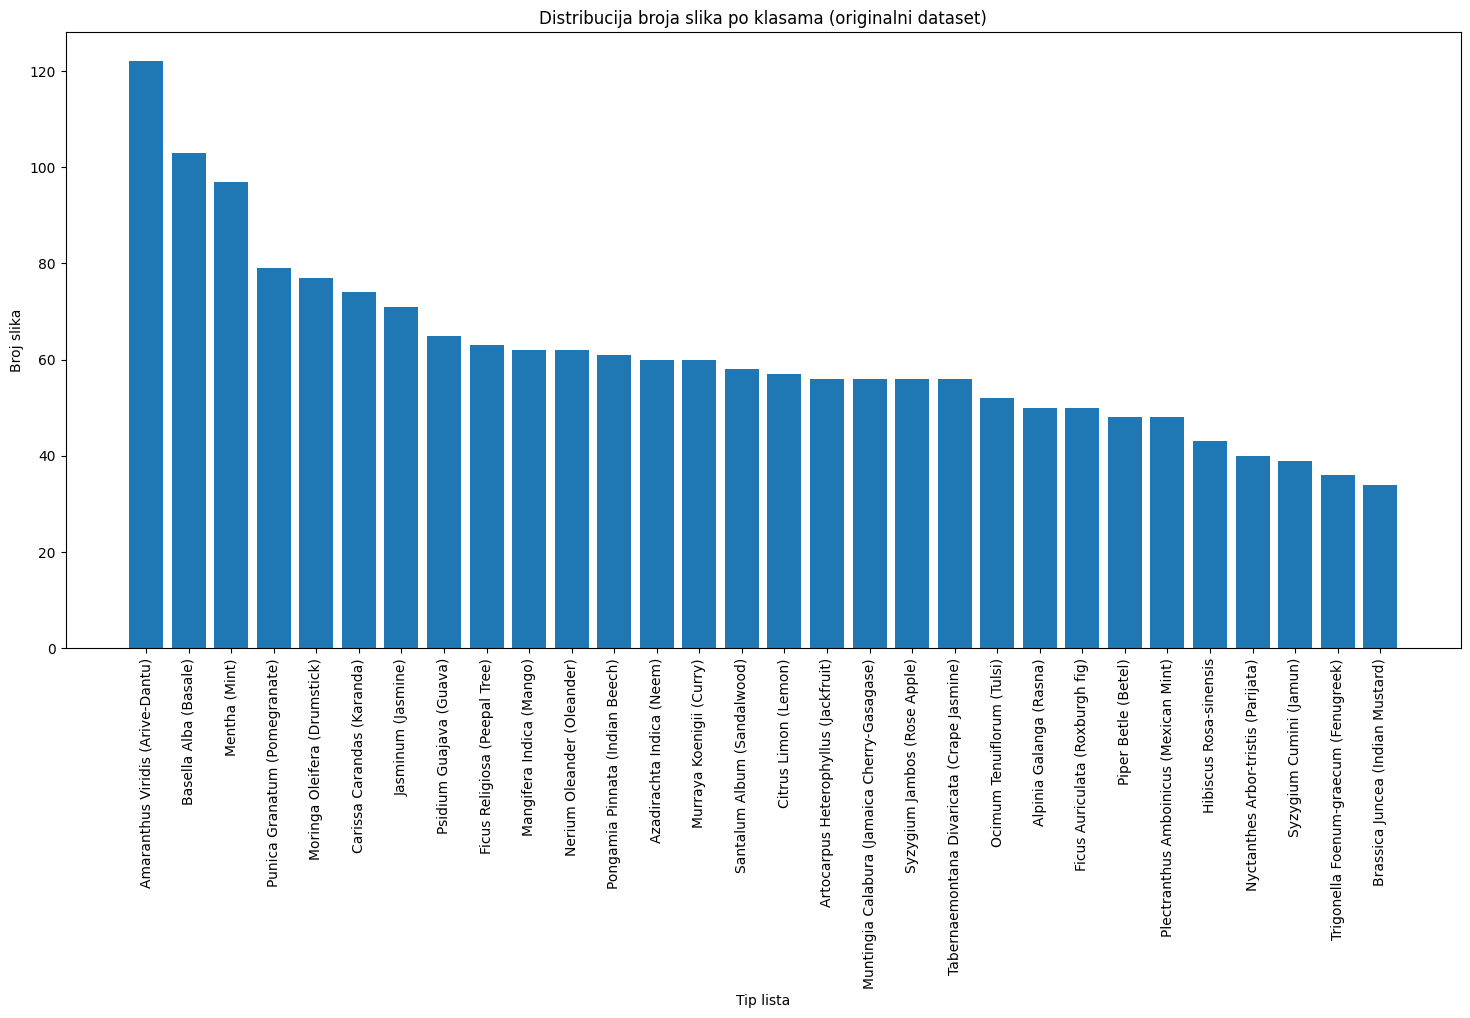

,image_path,leaf_type
0,data/Medicinal Leaf Dataset/Segmented Medicina...,Alpinia Galanga (Rasna)
1,data/Medicinal Leaf Dataset/Segmented Medicina...,Alpinia Galanga (Rasna)
2,data/Medicinal Leaf Dataset/Segmented Medicina...,Alpinia Galanga (Rasna)
3,data/Medicinal Leaf Dataset/Segmented Medicina...,Alpinia Galanga (Rasna)
4,data/Medicinal Leaf Dataset/Segmented Medicina...,Alpinia Galanga (Rasna)


In [57]:
df = build_dataframe(DATA_DIR)
plot_class_distribution(df, title="Distribucija broja slika po klasama (originalni dataset)")
df.head()

Vidi se da neke vrste biljaka imaju mnogo manje slika od drugih. To je
problem jer model onda malo "vidi" te vrste i teže ih uči - ovo ćemo
kasnije popraviti.

## 2. Prikaz uzorka slika

Radi provere da je sve učitano kako treba, pogledajmo par nasumičnih
slika i njihove oznake.

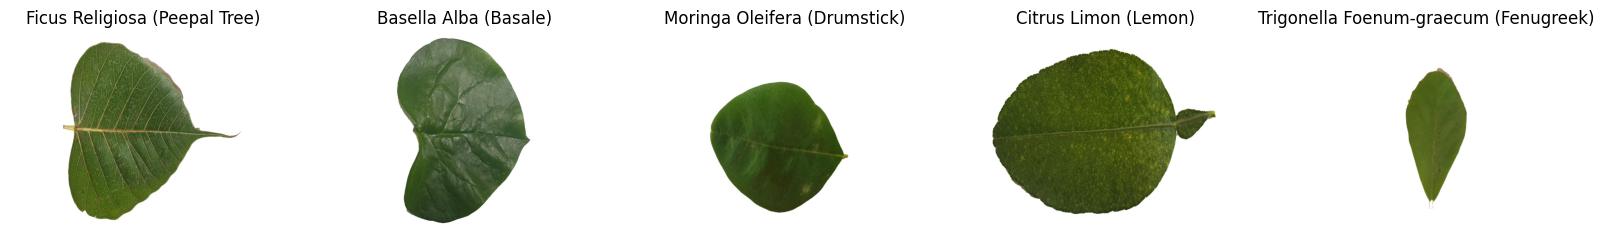

In [58]:
show_sample_images(df, n=5)

## 3. Podela na trening i test skup

Deo slika izdvajamo za treniranje modela, a deo ostavljamo po strani za
kasniju proveru koliko je model zapravo dobar. Test deo se ne dira do
same provere na kraju - model ga uopšte ne vidi tokom učenja.

In [59]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["leaf_type"],
)

print(f"Trening skup: {len(train_df)} slika")
print(f"Test skup:    {len(test_df)} slika")

Trening skup: 1468 slika
Test skup:    367 slika


## 4. Dopunjavanje trening skupa

Vrstama biljaka kojih ima malo dodajemo veštački napravljene varijante
postojećih slika (blago rotirane, okrenute, sa promenjenim osvetljenjem
i slično), tako da na kraju sve vrste imaju sličan broj slika za
treniranje. Ovaj korak se odnosi samo na trening skup - test skup
ostaje potpuno netaknut.

In [60]:
augment_transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.RandomRotation(degrees=45),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1),
])
AUGMENTED_DATASET_DIR = "data/augmented_dataset"
save_augmented_dataset(train_df, AUGMENTED_DATASET_DIR, augment_transform, target_count=300)

Augmentacija već urađena u 'data/augmented_dataset', preskačem.


Ukupan broj slika: 9000


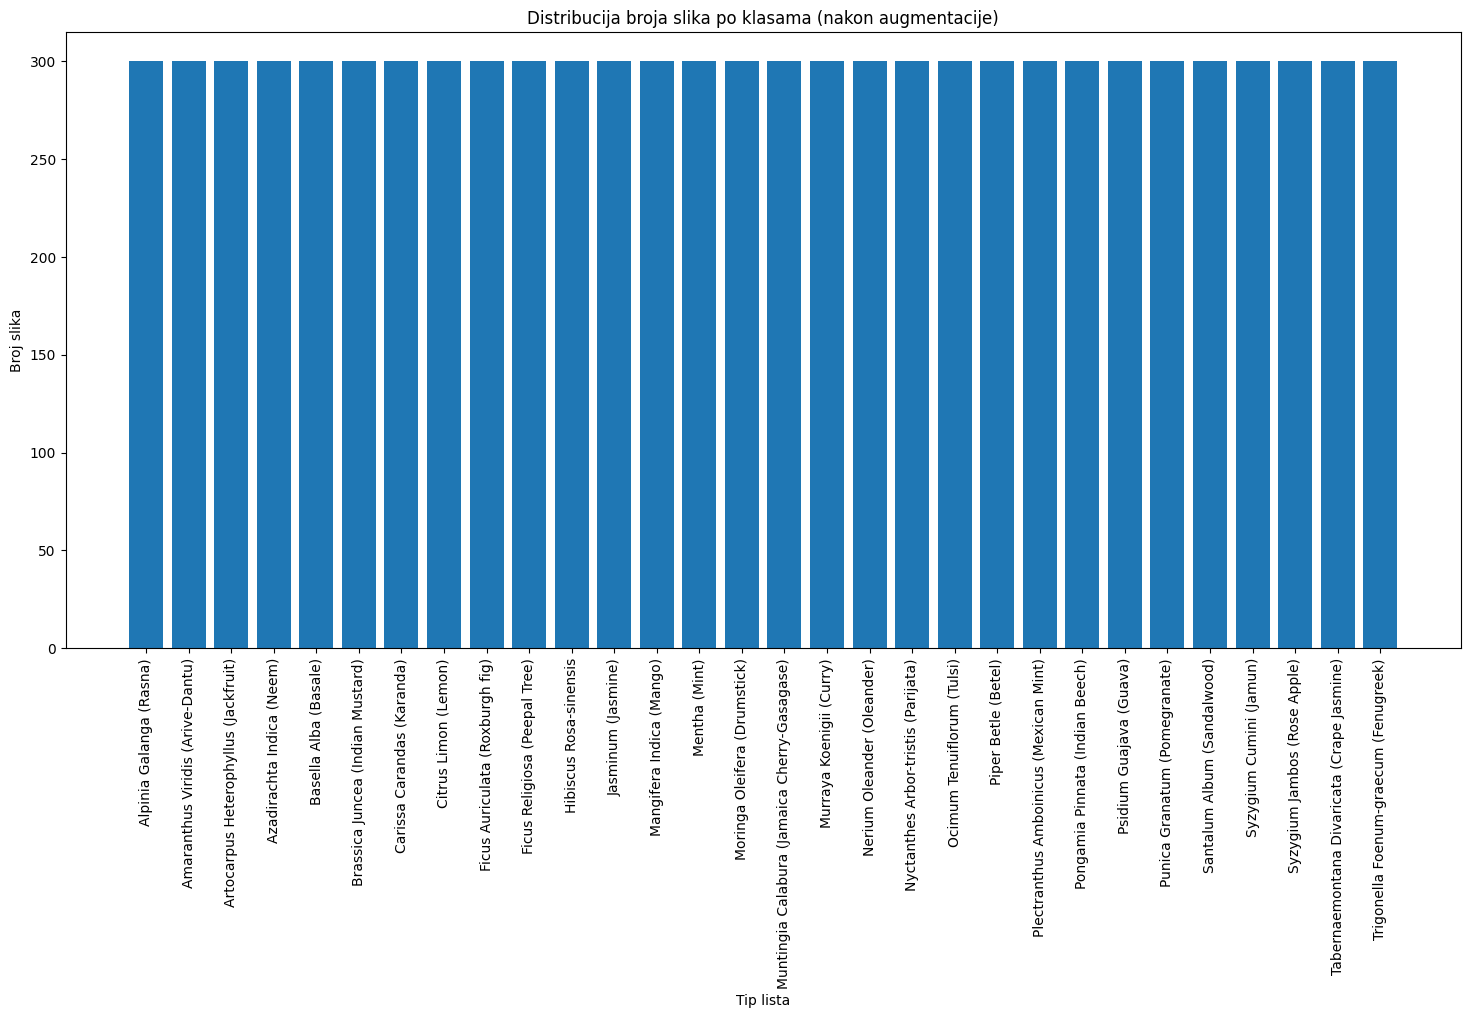

In [61]:
df_augmented = build_dataframe(AUGMENTED_DATASET_DIR)
plot_class_distribution(df_augmented, title="Distribucija broja slika po klasama (nakon augmentacije)")

Sada su vrste biljaka zastupljene ravnomernije, što modelu olakšava
učenje - nema više vrsta koje su drastično "u manjini".

Pored toga nismo koristili nijedan metod augmentacije koji bi moga da promeni boji lista

## 5. Priprema trening skupa za model

Dopunjeni skup slika sada pripremamo u obliku koji model može da čita
tokom treniranja.

In [62]:
transform_train = transforms.Compose([
    transforms.ToTensor(),
])

batch_size = 128
train = datasets.ImageFolder(root=AUGMENTED_DATASET_DIR, transform=transform_train)

print("Broj slika u trening dataset-u:", len(train))
print("Mapiranje klasa:", train.class_to_idx)

Broj slika u trening dataset-u: 9000
Mapiranje klasa: {'Alpinia Galanga (Rasna)': 0, 'Amaranthus Viridis (Arive-Dantu)': 1, 'Artocarpus Heterophyllus (Jackfruit)': 2, 'Azadirachta Indica (Neem)': 3, 'Basella Alba (Basale)': 4, 'Brassica Juncea (Indian Mustard)': 5, 'Carissa Carandas (Karanda)': 6, 'Citrus Limon (Lemon)': 7, 'Ficus Auriculata (Roxburgh fig)': 8, 'Ficus Religiosa (Peepal Tree)': 9, 'Hibiscus Rosa-sinensis': 10, 'Jasminum (Jasmine)': 11, 'Mangifera Indica (Mango)': 12, 'Mentha (Mint)': 13, 'Moringa Oleifera (Drumstick)': 14, 'Muntingia Calabura (Jamaica Cherry-Gasagase)': 15, 'Murraya Koenigii (Curry)': 16, 'Nerium Oleander (Oleander)': 17, 'Nyctanthes Arbor-tristis (Parijata)': 18, 'Ocimum Tenuiflorum (Tulsi)': 19, 'Piper Betle (Betel)': 20, 'Plectranthus Amboinicus (Mexican Mint)': 21, 'Pongamia Pinnata (Indian Beech)': 22, 'Psidium Guajava (Guava)': 23, 'Punica Granatum (Pomegranate)': 24, 'Santalum Album (Sandalwood)': 25, 'Syzygium Cumini (Jamun)': 26, 'Syzygium Jamb

## 6. Model

Ovde je definisan model koji uči da prepoznaje vrstu biljke na osnovu
slike lista. Mreža prvo kroz nekoliko slojeva izvlači vizuelne
karakteristike sa slike (oblik, teksturu, ivice...), a zatim na osnovu
toga donosi odluku kojoj od 30 vrsta biljka najverovatnije pripada.

In [63]:
class MedicaLeafCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),   # 224x224x3   224x224x16
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.MaxPool2d(2, 2),                            # 112x112x16

            nn.Conv2d(16, 32, kernel_size=3, padding=1),   # 112x112x32
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2, 2),                            # 56x56x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),   # 56x56x64
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2, 2),                            # 28x28x64

            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # 28x28x128
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2, 2),                            # 14x14x128
        )

        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(14 * 14 * 128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 30),  # 30 klasa
        )

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

## 7. Trening modela

Deo trening skupa ostavljamo po strani (validacioni skup) da bismo
tokom učenja mogli da pratimo kako se model ponaša na slikama koje
trenutno ne koristi za učenje. Model zatim prolazi kroz podatke više
puta (epoha) i postepeno uči da prepoznaje vrste biljaka.

In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Uređaj:", device)

loss_func = nn.CrossEntropyLoss()
model = MedicaLeafCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=3e-4)
num_epochs = 10

targets = train.targets
train_idx, val_idx = train_test_split(
    list(range(len(train))),
    test_size=0.2,
    stratify=targets,
    random_state=42,
)

train_set = Subset(train, train_idx)
val_set = Subset(train, val_idx)
g = torch.Generator()
g.manual_seed(42)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, generator=g)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

training_losses, val_losses = train_model(
    model, train_loader, val_loader, optimizer, loss_func, device, num_epochs
)

Uređaj: cuda
Epoha 1/10 | Train loss: 2.1931 | Val loss: 2.5971 | Accuracy: 0.2867
Epoha 2/10 | Train loss: 1.0918 | Val loss: 1.0164 | Accuracy: 0.8622
Epoha 3/10 | Train loss: 0.5214 | Val loss: 0.6921 | Accuracy: 0.9183
Epoha 4/10 | Train loss: 0.2243 | Val loss: 0.5273 | Accuracy: 0.9317
Epoha 5/10 | Train loss: 0.1099 | Val loss: 0.4519 | Accuracy: 0.9383
Epoha 6/10 | Train loss: 0.0620 | Val loss: 0.4231 | Accuracy: 0.9339
Epoha 7/10 | Train loss: 0.0434 | Val loss: 0.3948 | Accuracy: 0.9389
Epoha 8/10 | Train loss: 0.0324 | Val loss: 0.3624 | Accuracy: 0.9400
Epoha 9/10 | Train loss: 0.0262 | Val loss: 0.3492 | Accuracy: 0.9389
Epoha 10/10 | Train loss: 0.0209 | Val loss: 0.3392 | Accuracy: 0.9422


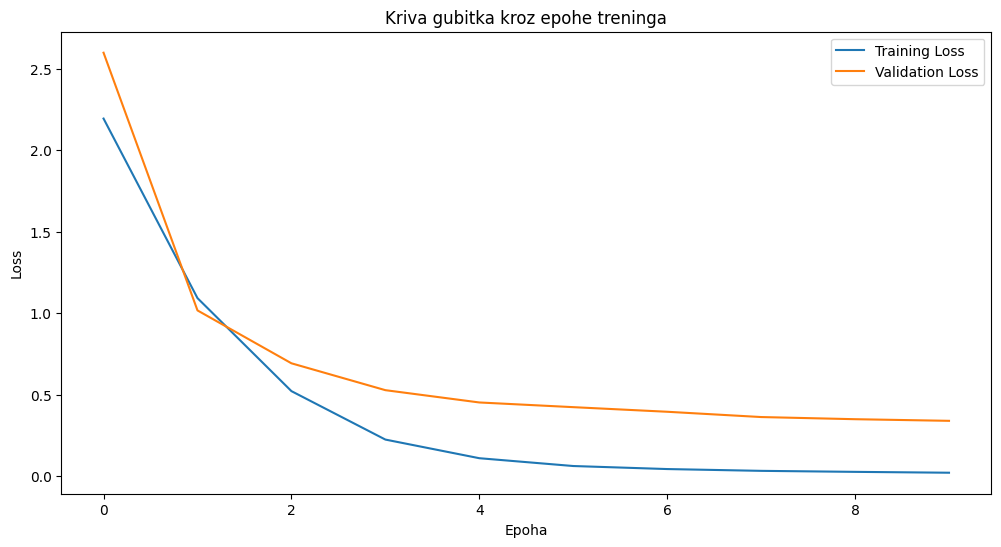

In [65]:
plot_losses(training_losses, val_losses)

Grafik pokazuje da li model tokom treninga zaista uči (greška opada) i
da li i dalje dobro radi na podacima koje nije direktno koristio za
učenje (validacioni deo).


Dato je uočiti da model uči, da ne overfituje i da je na kraju treninga postigao dobru tačnost na validacionom skupu.

## 8. Test skup

Test slike se ovde ne dupliraju i ne čuvaju posebno na disku, već se
učitavaju direktno sa njihovog originalnog mesta - onako kako su i
izdvojene u trećem koraku. Time je sigurno da model na kraju vidi baš
originalne, neizmenjene slike.

In [66]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

test_dataset = LeafDataset(
    test_df,
    transform=test_transform,
    class_to_idx=train.class_to_idx,
)

test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Broj test slika: {len(test_dataset)}")
print(f"Broj batch-eva: {len(test_loader)}")

Broj test slika: 367
Broj batch-eva: 3


## 9. Provera uspešnosti modela

Sada proveravamo koliko je model zaista dobar - gledano po vrsti
biljke, ne samo u proseku - kako bismo videli koje vrste model dobro
prepoznaje, a kod kojih najčešće greši.

In [67]:
results = evaluate_model(
    model,
    test_loader,
    loss_func,
    device,
    class_names=test_dataset.classes,
)

Test Loss: 0.3887
Test Accuracy: 92.37%
F1 Score: 92.44%
                                              precision    recall  f1-score   support

                     Alpinia Galanga (Rasna)       0.91      1.00      0.95        10
            Amaranthus Viridis (Arive-Dantu)       0.93      1.00      0.96        25
        Artocarpus Heterophyllus (Jackfruit)       1.00      0.91      0.95        11
                   Azadirachta Indica (Neem)       0.91      0.83      0.87        12
                       Basella Alba (Basale)       1.00      1.00      1.00        21
            Brassica Juncea (Indian Mustard)       1.00      0.86      0.92         7
                  Carissa Carandas (Karanda)       1.00      1.00      1.00        15
                        Citrus Limon (Lemon)       0.75      0.82      0.78        11
             Ficus Auriculata (Roxburgh fig)       0.78      0.70      0.74        10
               Ficus Religiosa (Peepal Tree)       1.00      1.00      1.00       

## 10. Zaključak

Model je naučen na dopunjenom skupu slika listova, a provera je urađena
na skupu koji tokom učenja uopšte nije video. Rezultati iznad pokazuju
koliko dobro model razlikuje pojedinačne vrste lekovitog bilja i kod
kojih vrsta najčešće dolazi do zabune.

Mozemo videti da modle najviše greši kod citrusa i kod  Roxiburg fig 
Pored ovoga mozemo zaključiti da je model naučio da razlikuje vrste lekovitog bilja i da tačnost na test skupu iznosi 92% što je odličan rezultat.